# Exercício:

In [ ]:

import pandas as pd
df_data = pd.read_csv('../storage/aula_004.csv')
df_data  = df_data.drop('gene_name', axis=1)


## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

https://1drv.ms/v/c/808ebfd9a0d86213/IQCLY6g2vuPjQr-7RxF_QZK0AWue-PxKWmQ8QlMEtwIh2WA?e=qBwOpD

In [66]:
def read_fasta(path:str):
  with open(path, 'r') as f:
    return f.read()

APOE_fasta = read_fasta("../storage/genes/APOE.fasta")
BRCA1_fasta = read_fasta("../storage/genes/BRCA1.fasta")
EGFR_fasta = read_fasta("../storage/genes/EGFR.fasta")
TP53_fasta = read_fasta("../storage/genes/TP53.fasta")
VEGFA_fasta = read_fasta("../storage/genes/VEGFA.fasta")
genes = ["APOE", "BRCA1", "EGFR", "TP53", "VEGFA"]

In [67]:
def parse_fasta(fasta_str):
    lines = fasta_str.strip().split("\n")
    header = lines[0]
    seq = "".join(lines[1:])  # junta todas as linhas da sequência
    # header geralmente começa com '>'
    header_parts = header[1:].split()
    ref_code = header_parts[0]   # código de referência
    sigla = header_parts[1] if len(header_parts) > 1 else None
    return sigla, ref_code, seq


In [68]:
genes_data = []

for gene_name, fasta in zip(genes, [APOE_fasta, BRCA1_fasta, EGFR_fasta, TP53_fasta, VEGFA_fasta]):
    sigla, ref_code, seq = parse_fasta(fasta)
    genes_data.append({
        "gene_name": gene_name,
        "sigil": sigla,
        "ref_code": ref_code,
        "sequence": seq
    })

df_genes = pd.DataFrame(genes_data).set_index("gene_name")
df_genes.to_csv("../storage/aula_013.csv")
print(df_genes.head())


              sigil                ref_code  \
gene_name                                     
APOE       RecName:  sp|P02649.1|APOE_HUMAN   
BRCA1         BRCA1              AAC37594.1   
EGFR           EGFR              AAI18666.1   
TP53          TP53,              AYF55702.1   
VEGFA         VEGFA            CAP2943360.1   

                                                    sequence  
gene_name                                                     
APOE       MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQSGQRWEL...  
BRCA1      MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...  
EGFR       MAAEDVIICAQQCSGRCRGKSPSDCCHNQCAAGCTGPRESDCLVCR...  
TP53               WVDSTPPPGTRVRAVAIYKQSQHMTEVVRRCPHHERCSDSD  
VEGFA      MFKAVRGQRSPHHSSALAGNVGHIISHRHENKGRLQAARLFTLFVQ...  


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [69]:
aminoacids = list("ACDEFGHIKLMNPQRSTVWY")
def count_aminoacids(seq):
    return {aa: seq.count(aa) for aa in aminoacids}
counts = df_genes['sequence'].apply(count_aminoacids)
df_counts = pd.DataFrame(list(counts), index=df_genes.index)
df_genes = pd.concat([df_genes, df_counts], axis=1)

print(df_genes.head())


              sigil                ref_code  \
gene_name                                     
APOE       RecName:  sp|P02649.1|APOE_HUMAN   
BRCA1         BRCA1              AAC37594.1   
EGFR           EGFR              AAI18666.1   
TP53          TP53,              AYF55702.1   
VEGFA         VEGFA            CAP2943360.1   

                                                    sequence   A   C   D    E  \
gene_name                                                                       
APOE       MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQSGQRWEL...  39   2  11   40   
BRCA1      MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...  84  44  85  198   
EGFR       MAAEDVIICAQQCSGRCRGKSPSDCCHNQCAAGCTGPRESDCLVCR...  25  42  22   27   
TP53               WVDSTPPPGTRVRAVAIYKQSQHMTEVVRRCPHHERCSDSD   2   2   3    2   
VEGFA      MFKAVRGQRSPHHSSALAGNVGHIISHRHENKGRLQAARLFTLFVQ...  11  17   9   18   

            F   G   H  ...   M    N   P   Q   R    S    T    V   W   Y  
gene_name              ...   

## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [70]:
print(df_genes['V'])

gene_max_valina = df_genes['V'].idxmax()

max_valina = df_genes['V'].max()

print(gene_max_valina, max_valina)

gene_name
APOE      24
BRCA1    101
EGFR      26
TP53       5
VEGFA     14
Name: V, dtype: int64
BRCA1 101


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [71]:

serina_counts = df_genes['S']
print(serina_counts)
media = serina_counts.mean()      
mediana = serina_counts.median()  
moda = serina_counts.mode()[0]    

print(f"Média: {media}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")


gene_name
APOE      14
BRCA1    224
EGFR      26
TP53       4
VEGFA     14
Name: S, dtype: int64
Média: 56.4
Mediana: 14.0
Moda: 14


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

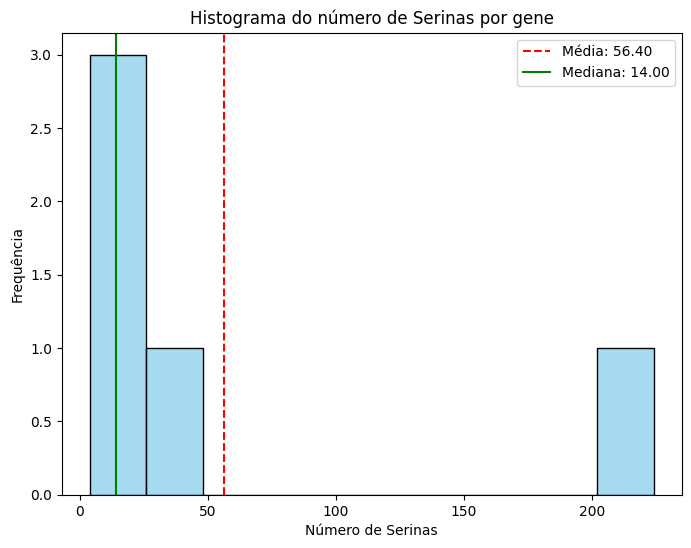

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.histplot(serina_counts, bins=10, kde=False, color="skyblue")

plt.axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')

plt.title("Histograma do número de Serinas por gene")
plt.xlabel("Número de Serinas")
plt.ylabel("Frequência")
plt.legend()

plt.show()


## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

def analisar_aminoacido(df, aa: str):
    """
    df: DataFrame com as sequências e colunas de contagem de aminoácidos
    aa: Nome do aminoácido por extenso (primeira letra maiúscula, igual à chave do dicionário)
    """
    amino_dict = {
        "Alanina": "A",
        "Cisteína": "C",
        "Ácido aspártico": "D",
        "Ácido glutâmico": "E",
        "Fenilalanina": "F",
        "Glicina": "G",
        "Histidina": "H",
        "Isoleucina": "I",
        "Lisina": "K",
        "Leucina": "L",
        "Metionina": "M",
        "Asparagina": "N",
        "Prolina": "P",
        "Glutamina": "Q",
        "Arginina": "R",
        "Serina": "S",
        "Treonina": "T",
        "Valina": "V",
        "Triptofano": "W",
        "Tirosina": "Y"
    }

    # tenta mapear o nome para a letra
    try:
        aminoacid = amino_dict[aa]
    except KeyError:
        raise Exception(f"Argumento inválido. Deve ser um dos: {list(amino_dict.keys())}")

    counts = df[aminoacid]

    media = counts.mean()
    mediana = counts.median()
    moda = counts.mode()[0]

    print(f"Análise para {aa}:")
    print(f"Média: {media}")
    print(f"Mediana: {mediana}")
    print(f"Moda: {moda}")

    plt.figure(figsize=(8,6))
    sns.histplot(counts, bins=10, kde=False, color="skyblue")

    plt.axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
    plt.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')

    plt.title(f"Histograma do número de {aa} por gene")
    plt.xlabel(f"Número de {aa}")
    plt.ylabel("Frequência")
    plt.legend()
    plt.show()


## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

Análise para Glutamina:
Média: 31.0
Mediana: 13.0
Moda: 2


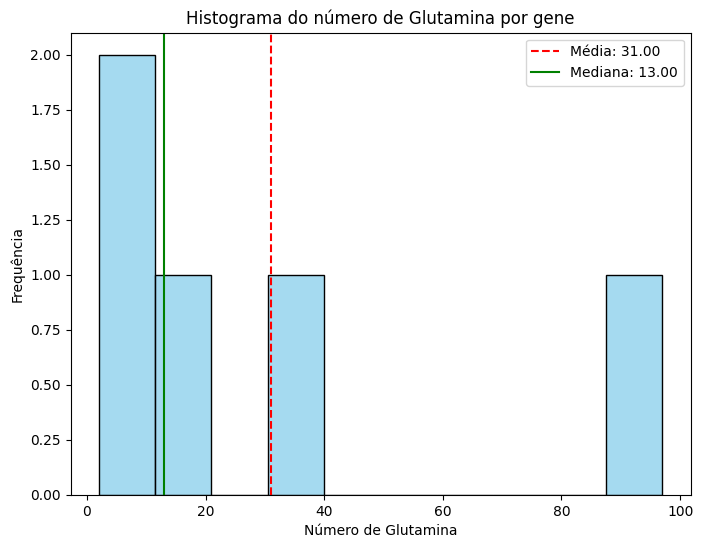

Análise para Glicina:
Média: 32.2
Mediana: 18.0
Moda: 1


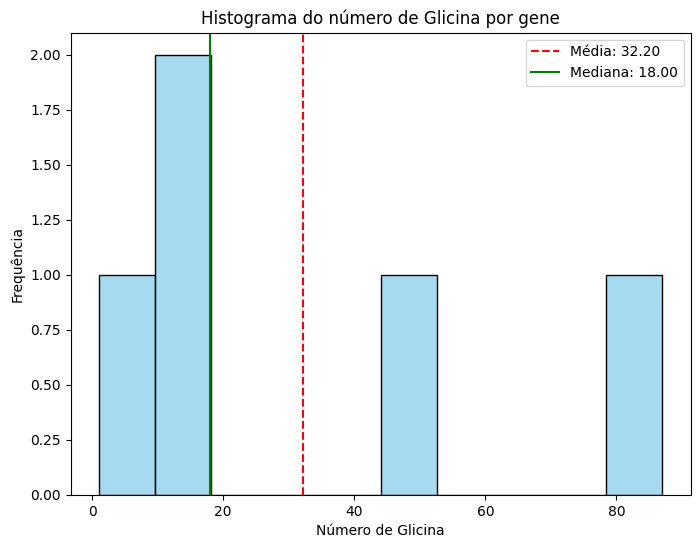

Análise para Lisina:
Média: 39.0
Mediana: 17.0
Moda: 1


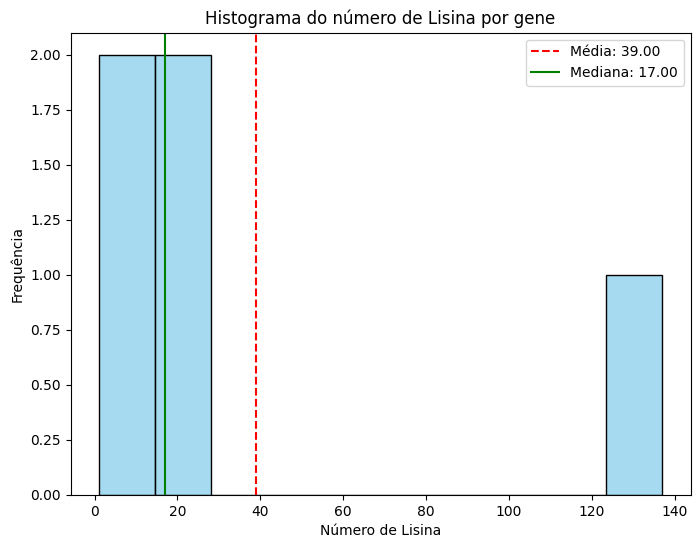

Análise para Valina:
Média: 34.0
Mediana: 24.0
Moda: 5


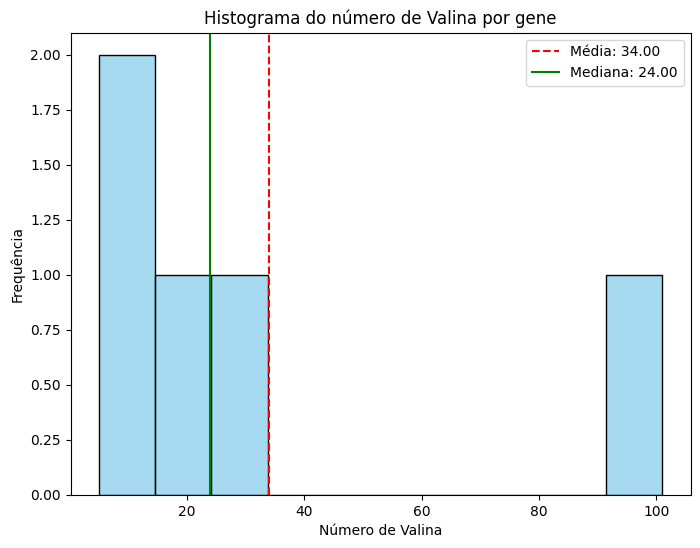

In [74]:
amino_list = ["Glutamina", "Glicina", "Lisina" , "Valina"]
for aa in amino_list:
  analisar_aminoacido(df_genes, aa)

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [75]:
primeiros_genes = df_genes.head(3)
cisteina_counts = primeiros_genes['C']
media = cisteina_counts.mean()
mediana = cisteina_counts.median()
print("Número de Cisteínas nos três primeiros genes:")
print(cisteina_counts)
print(f"Média: {media}")
print(f"Mediana: {mediana}")

Número de Cisteínas nos três primeiros genes:
gene_name
APOE      2
BRCA1    44
EGFR     42
Name: C, dtype: int64
Média: 29.333333333333332
Mediana: 42.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [76]:

df_amino = df_genes[aminoacids]

df_genes['media_aa'] = df_amino.mean(axis=1)

gene_max = df_genes['media_aa'].idxmax()
valor_max = df_genes['media_aa'].max()

print(df_genes[['media_aa']])
print(f"O gene com maior número médio de aminoácidos é {gene_max}, com média {valor_max:.2f}.")
df_genes

           media_aa
gene_name          
APOE          15.85
BRCA1         93.15
EGFR          23.20
TP53           2.05
VEGFA         11.05
O gene com maior número médio de aminoácidos é BRCA1, com média 93.15.


,sigil,ref_code,sequence,A,C,D,E,F,G,H,...,N,P,Q,R,S,T,V,W,Y,media_aa
gene_name,,,,,,,,,,,,,,,,,,,,,
APOE,RecName:,sp|P02649.1|APOE_HUMAN,MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQSGQRWEL...,39,2,11,40,4,18,2,...,1,8,32,34,14,12,24,8,4,15.85
BRCA1,BRCA1,AAC37594.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,84,44,85,198,49,87,49,...,121,96,97,76,224,111,101,10,31,93.15
EGFR,EGFR,AAI18666.1,MAAEDVIICAQQCSGRCRGKSPSDCCHNQCAAGCTGPRESDCLVCR...,25,42,22,27,11,45,15,...,26,28,13,22,26,28,26,4,9,23.20
TP53,"TP53,",AYF55702.1,WVDSTPPPGTRVRAVAIYKQSQHMTEVVRRCPHHERCSDSD,2,2,3,2,0,1,3,...,0,4,2,5,4,3,5,1,1,2.05
VEGFA,VEGFA,CAP2943360.1,MFKAVRGQRSPHHSSALAGNVGHIISHRHENKGRLQAARLFTLFVQ...,11,17,9,18,10,10,12,...,7,12,11,20,14,7,14,1,4,11.05


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [81]:
gene_min = df_genes['media_aa'].idxmin()
valor_min = df_genes['media_aa'].min()

print(df_genes[['media_aa']])
print(f"O gene com menor número médio de aminoácidos é {gene_min}, com média {valor_min:.2f}.")


           media_aa
gene_name          
APOE          15.85
BRCA1         93.15
EGFR          23.20
TP53           2.05
VEGFA         11.05
O gene com menor número médio de aminoácidos é TP53, com média 2.05.
